# This Notebook is used to create a visual representation of the features found in each pose in the pose graph.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import json
from PIL import Image
import os

### Reading in Landmarks

In [2]:

folder_path = '/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/landmark_results'
file_count_landmarks = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
print(f"Number of files: {file_count_landmarks}")

landmark_points = []

for i in range(0,file_count_landmarks,1):
    x=[]
    y=[]
    z=[]
    filename = filename=folder_path+f"/points_{i:04d}.txt"
    with open(filename, 'r') as file:
        # count = 0
        for line in file:
            # count += 1
            # if count >10:
            #     break
            if not line.strip():
                continue
            else:
                row = [float(val) for val in line.strip().split(",")]
                if row[0] < 50.0 and -row[1] < 50.0 and -row[1] > -0.2 and row[2] < 20.0 and row[2]> 0.0:
                    x.append(-row[0])
                    y.append(-row[1])
                    z.append(row[2])
    temp = np.array([x, y, z])
    landmark_points.append(temp)
print("number of points in 1: ", len(landmark_points[0][0]))
print("size: ",landmark_points[0].shape)
print("point: ",landmark_points[0][:,0])



Number of files: 90
number of points in 1:  484
size:  (3, 484)
point:  [2.13955 1.35742 3.04458]


In [3]:
vertex_num = 0

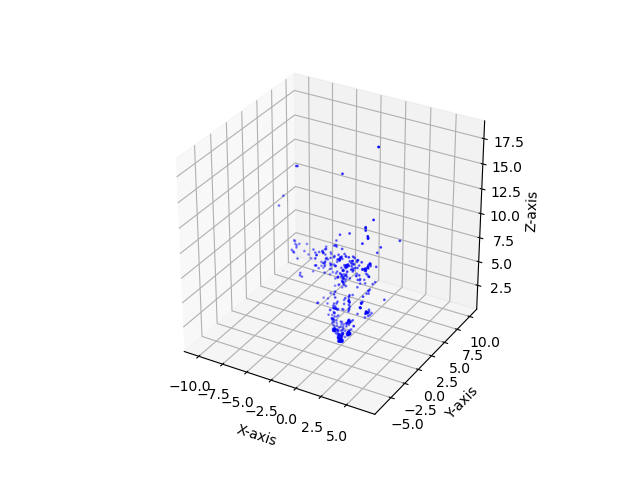

In [16]:
%matplotlib ipympl

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(landmark_points[vertex_num][0], landmark_points[vertex_num][1], landmark_points[vertex_num][2], c='blue', marker='o', s=1) # s for size
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')


Px, Py, Pz = landmark_points[vertex_num][0], landmark_points[vertex_num][1], landmark_points[vertex_num][2]
max_range = np.array([Px.max()-Px.min(), Py.max()-Py.min(), Pz.max()-Pz.min()]).max() / 2.0

mid_x = (Px.max()+Px.min()) * 0.5
mid_y = (Py.max()+Py.min()) * 0.5
mid_z = (Pz.max()+Pz.min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)
ax.set_box_aspect([1, 1, 1])  
plt.show()

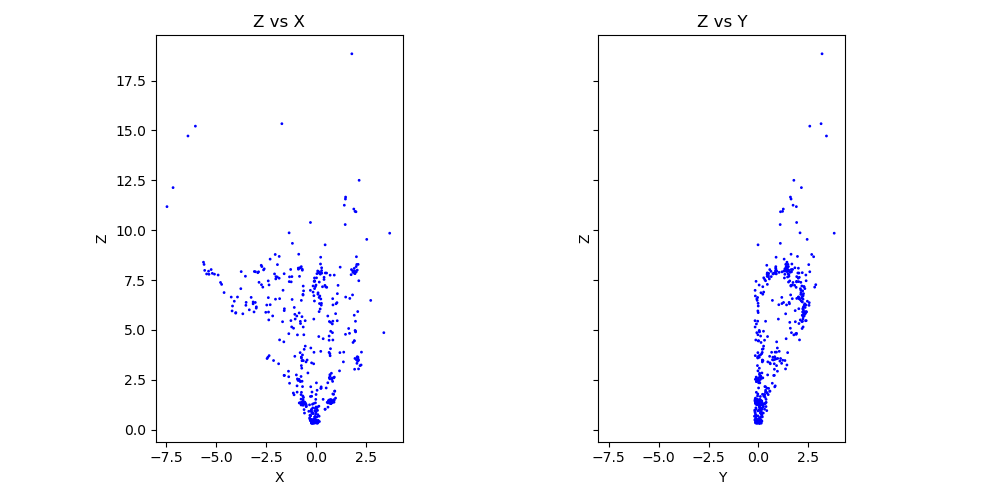

In [15]:
%matplotlib ipympl

s = np.ones(len(landmark_points[vertex_num][0]))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5),sharex=True, sharey=True)

ax1.scatter(landmark_points[vertex_num][0], landmark_points[vertex_num][2], s=s, color='blue', label='Group 1')
ax1.set_aspect('equal')
ax1.set_xlabel("X")
ax1.set_ylabel("Z")
ax1.set_title("Z vs X")

ax2.scatter(landmark_points[vertex_num][1], landmark_points[vertex_num][2], s=s, color='blue', label='Group 1')
ax2.set_aspect('equal')
ax2.set_xlabel("Y")
ax2.set_ylabel("Z")
ax2.set_title("Z vs Y")

plt.tight_layout()
plt.show()

### Reading in odom of the robot

In [6]:
edges=[]
from_ids=[]
to_ids=[]
folder_path = '/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/edge_results'
file_count_edges = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
print(f"Number of files: {file_count_edges}")
for i in range(0,file_count_edges,1):
    filename = filename=folder_path+f"/edge_{i:04d}.txt"
    matrix = []
    with open(filename, 'r') as file:
        for line in file:
            if line.startswith('from_vertex_id'):
                from_vertex_id = int(line.split(':')[1].strip())
                # print(f"From Vertex ID: {from_vertex_id}")
                from_ids.append(from_vertex_id)
            elif line.startswith('to_vertex_id'):
                to_vertex_id = int(line.split(':')[1].strip())
                # print(f"To Vertex ID: {to_vertex_id}")
                to_ids.append(to_vertex_id)
            elif line.strip() and not line.startswith('u'):
                row = [float(val) for val in line.strip().split()]
                matrix.append(row)
    edges.append(np.array(matrix[0:4]))
#poses=np.array(poses)

Number of files: 89


### Sort the edges into correct order

In [7]:
def bubble_sort(arr1, arr2, arr3):
    for i in range(len(arr1)):
        # Last i elements are already in place
        for j in range(0, len(arr1) - i - 1):
            if arr1[j] > arr1[j + 1]:
                # Swap if elements are in the wrong order
                arr1[j], arr1[j + 1] = arr1[j + 1], arr1[j]
                arr2[j], arr2[j + 1] = arr2[j + 1], arr2[j]
                arr3[j], arr3[j + 1] = arr3[j + 1], arr3[j]
    return np.array(arr1), np.array(arr2), np.array(arr3)

# Example usage:
my_list = [5, 2, 9, 1, 5, 6]
sorted_from, sorted_to, sorted_edges = bubble_sort(from_ids.copy(), to_ids.copy(), edges.copy())
print("Sorted list:", sorted_from)
print("Corresponding to list:", sorted_to)

Sorted list: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88]
Corresponding to list: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89]


In [8]:
# creating new matrices:
vertex_poses = []
pose1 = np.array([
    [-1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
vertex_poses.append(pose1)
for i in range(0,sorted_from.__len__(),1):
    temp_pose =  vertex_poses[i] @ sorted_edges[i] 
    vertex_poses.append(temp_pose)
print(vertex_poses[0])
vertex_poses = np.array(vertex_poses)

[[-1  0  0  0]
 [ 0  1  0  0]
 [ 0  0  1  0]
 [ 0  0  0  1]]


In [9]:
print(vertex_poses[5][:3,:3])

[[-0.99988849  0.01289473  0.0075377 ]
 [ 0.01285615  0.99990451 -0.00514645]
 [ 0.00760339  0.00504897  0.99995774]]


[[ 0.          0.          0.        ]
 [ 0.35754     0.00370012  0.0120787 ]
 [ 0.85556608 -0.0008633   0.02842913]]


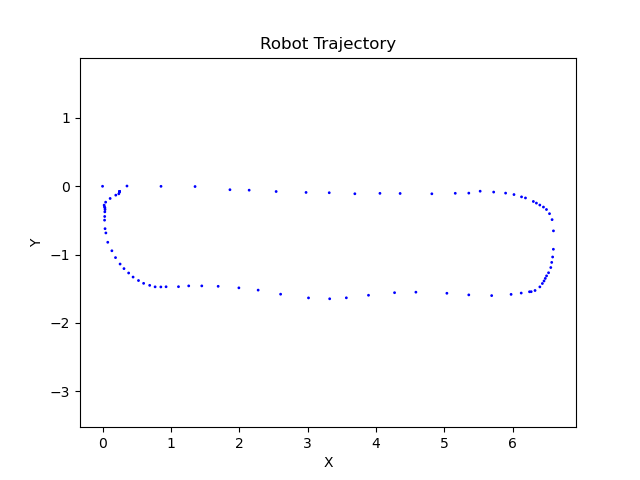

In [10]:
%matplotlib ipympl
origins = vertex_poses[:, :3, -1]
print(origins[0:3])
dirs = np.stack([np.sum([1, 0, 0] * pose[:3, :3], axis=-1) for pose in vertex_poses])
x_plot= origins[..., 0].flatten()
y_plot= origins[..., 1].flatten()
z_plot= origins[..., 2].flatten()
#print(np.array(x))
# print(type(x))
s = np.ones(len(x_plot))
#plt.scatter(x=x, y=y, color='red')
plt.scatter(x_plot, y_plot, s=s, color='blue', label='Group 1')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Robot Trajectory")
plt.axis('equal')
plt.show()

### Migrate Landmarks

In [11]:
def rotate_xyz(point, theta_x, theta_y, theta_z):
    # Rotation about Y axis
    R_x = np.array([
        [1, 0, 0],
        [0, np.cos(theta_x), np.sin(theta_x)],
        [0, -np.sin(theta_x),  np.cos(theta_x)]
    ])

    R_y = np.array([
        [np.cos(theta_y), 0, -np.sin(theta_y)],
        [0, 1, 0],
        [np.sin(theta_y), 0, np.cos(theta_y)]
    ])

    # Rotation about Z axis
    R_z = np.array([
        [np.cos(theta_z), np.sin(theta_z), 0],
        [-np.sin(theta_z),  np.cos(theta_z), 0],
        [0, 0, 1]
    ])

    # Apply the rotations: first Y, then Z
    rotated =  R_z @ R_y @ R_x @ point
    return rotated

In [12]:
# creating new matrices:
migrate_poses = []
pose1 = np.array([
    [-1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
migrate_poses.append(pose1)
for i in range(0,sorted_from.__len__(),1):
    temp_pose =  migrate_poses[i] @ sorted_edges[i] 
    migrate_poses.append(temp_pose)
print(migrate_poses[0])
vertex_pmigrate_posesoses = np.array(migrate_poses)

[[-1  0  0  0]
 [ 0  1  0  0]
 [ 0  0  1  0]
 [ 0  0  0  1]]


In [13]:
theta_x = np.radians(-90)  # No rotation about X  0
theta_y = np.radians(0)  # 90 degrees about Y    90
theta_z = np.radians(-90)  # 45 degrees about Z    90


migrated_landmarks = []

for frame in range(file_count_landmarks):
    new_x = []
    new_y = []
    new_z = []
    for i in range(len(landmark_points[frame][0])):
        pt = np.array([landmark_points[frame][0][i], landmark_points[frame][1][i], landmark_points[frame][2][i]])
        rotated_pt = rotate_xyz(pt, theta_x, theta_y, theta_z)
        if frame == 0:
            new_x.append(rotated_pt[0])  #+ origins[frame][0]) 
            new_y.append(rotated_pt[1])  #+ origins[frame][1])
            new_z.append(rotated_pt[2])  #+ origins[frame][2])
        else:
            temp_pt = np.array([-rotated_pt[0], rotated_pt[1], rotated_pt[2], 1])
            # transform = np.eye(3)
            # for m in range(frame):
            #     transform = sorted_edges[m][:3, :3]@transform
            temp_pt = migrate_poses[frame-1]@ temp_pt
            
            new_x.append(temp_pt[0])  #+ origins[frame][0]) 
            new_y.append(temp_pt[1])  #+ origins[frame][1])
            new_z.append(temp_pt[2])  #+ origins[frame][2])

    migrated_landmarks.append(np.array([new_x, new_y, new_z]))

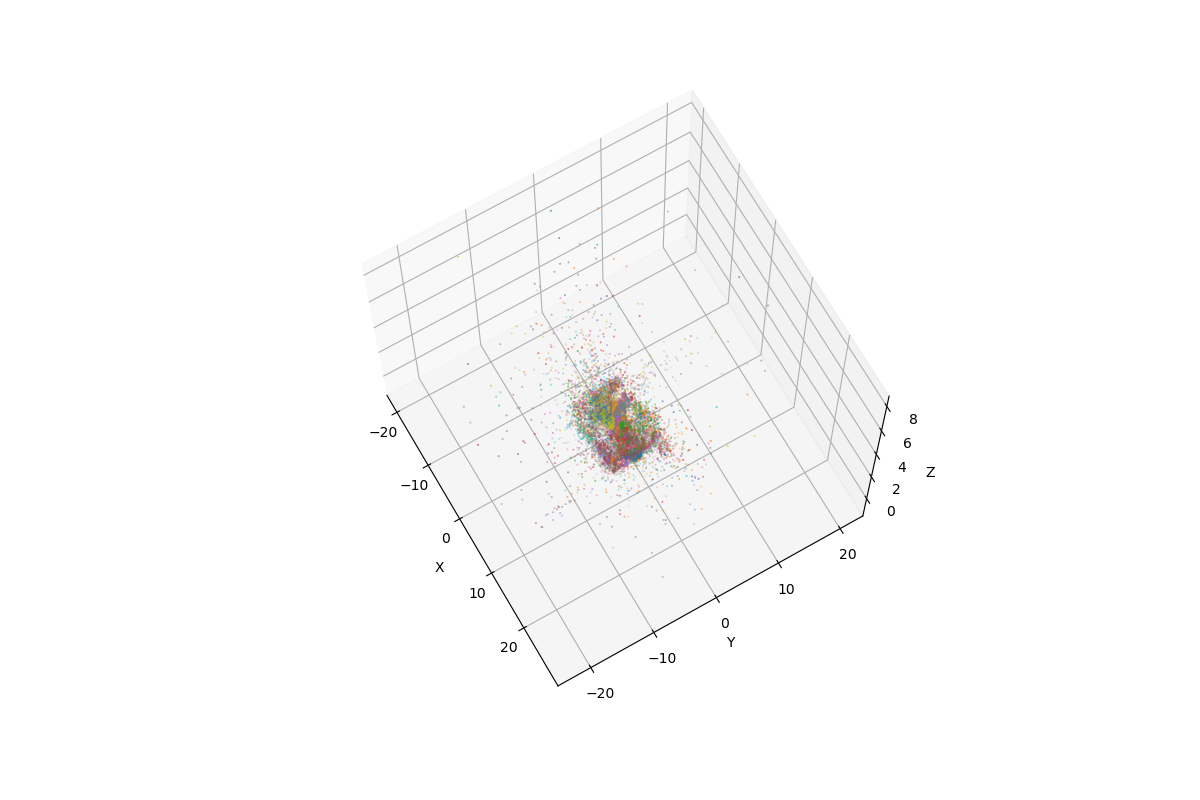

In [21]:
%matplotlib ipympl
ax = plt.figure(figsize=(12, 8)).add_subplot(projection='3d')
_ = ax.quiver(
  origins[..., 0].flatten(),
  origins[..., 1].flatten(),
  origins[..., 2].flatten(),
  -dirs[..., 0].flatten(),
  -dirs[..., 1].flatten(),
  -dirs[..., 2].flatten(), length=0.5, normalize=False)

# ax.scatter(
#     migrated_landmarks[0][0], 
#     migrated_landmarks[0][1], 
#     migrated_landmarks[0][2],
#     color='red', s=1, label='Origins')

# indices_to_plot = [0, 10, 20, 25, 30, 35, 40, 50]  # Add as many as you want
# colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
indices_to_plot = list(range(0, 90, 2)) 

for i, idx in enumerate(indices_to_plot):
    ax.scatter(
        migrated_landmarks[idx][0], 
        migrated_landmarks[idx][1], 
        migrated_landmarks[idx][2],
        # color=colors[i % len(colors)], 
        s=0.1, 
        label=f'Index {idx}')

ax.set_box_aspect([1,1,1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(70, -30) 
plt.show()